# LOFAR single station imaging

Based on version 1.4 of V.A. Moss's tutorial, tutorial from M.A. Brentjens 8/8/2017.

Updated February 2020 by T.J. Dijkema with aerial imagery backdrops.

This notebook is intended to explore the imaging of one XST file. To do all of the things in this notebook for a batch of XST files, have a look at the function `make_xst_plots` (`from lofarimaging import make_xst_plots`).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys
import time
import datetime
import glob
import numpy as np

from lofarantpos.db import LofarAntennaDatabase

In [3]:
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap, Normalize
import warnings
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib.axes as maxes
from matplotlib.ticker import FormatStrFormatter
import re

In [4]:
from astropy.coordinates import SkyCoord, GCRS, EarthLocation, AltAz, SkyOffsetFrame, CartesianRepresentation, get_sun, get_body
import astropy.units as u
from astropy.time import Time

In [5]:
# We need lofarantpos >= 0.4.0 to get the station rotations

from packaging import version
import lofarantpos
assert(version.parse(lofarantpos.__version__) >= version.parse("0.4.0"))

In [6]:
from lofarimaging import find_caltable, sb_from_freq, freq_from_sb, read_caltable, \
    read_acm_cube, get_map, sky_imager, ground_imager, get_station_pqr, get_station_type, \
    skycoord_to_lmn, nearfield_imager, make_leaflet_map, make_sky_plot, make_ground_plot, \
    apply_calibration, get_full_station_name, get_station_xyz

In [7]:
#get_station_pqr?

In [8]:
# We need python 3.6 for f-string formatting

assert(sys.version_info.major + 0.1*sys.version_info.minor >= 3.6)

In [9]:
# Define directories 
data_dir = "./test/new_mode4_sb205"
caltable_dir = "./test/CalTables"  # Root directory under which station information is stored in subdirectories DE602C/etc/, RS106/etc/, ...

In [10]:
# Define area of interest
# size and physical limits of the "projection" from LOFAR in meters
extent = [-600, 600, -600, 600]
#pixels_per_metre = 0.00005 # each pixel is 1km
pixels_per_metre = 0.3 # each pixel is 1km
height = -0.5 #meters

In [11]:
os.makedirs('results', exist_ok=True)

In [12]:
start1 = time.time()

In [13]:
# Read all available .dat files
print(f"Searching for available files in {data_dir}")
files = glob.glob(data_dir + "/*.dat")
for file_index, filename in enumerate(files):
    print(f"{file_index}: {filename}")

Searching for available files in ./test/new_mode4_sb205
0: ./test/new_mode4_sb205\20260331_132108_xst.dat


In [14]:
# Select a file
xst_filename = files[0]

print("File selected:", xst_filename)

File selected: ./test/new_mode4_sb205\20260331_132108_xst.dat


In [15]:
station_name = "LV614"

# RCU Mode: defines usable frequency band and filter characteristics
rcu_mode = xst_filename.split('mode')[1].split('_')[0]
print(rcu_mode)
subband = int(xst_filename.split('sb')[1].split('\\')[0])
print(subband)

obsdatestr, obstimestr, *_ = os.path.basename(xst_filename).rstrip(".dat").split("_")
print(obsdatestr, obstimestr)

4
205
20260331 132108


In [16]:
#rcu_mode = rcu_mode.replace("sparseeven", "sparse_even").replace("sparseodd", "sparse_odd")

In [17]:
station_type = get_station_type(station_name)

In [65]:
station_name = get_full_station_name(station_name, rcu_mode)

# Get the data
fname = f"{obsdatestr}_{obstimestr}_{station_name}_SB{subband}"

npix_l, npix_m = 131, 131
freq = freq_from_sb(subband, rcu_mode=rcu_mode)

# Which slice in time to visualise
timestep = 10

# For ground imaging
ground_resolution = pixels_per_metre  # pixels per metre for ground_imaging, default is 0.5 pixel/metre

obstime = datetime.datetime.strptime(obsdatestr + ":" + obstimestr, '%Y%m%d:%H%M%S')
print(obstime)

# Confirm the data has been read correctly
print(f"""Station: {station_name}
Station type: {station_type}
Subband: {subband}
Timestep: {timestep}
Save title: {fname}
Sky image size: {npix_l:d} x {npix_m:d}
Ground image extent: {extent[1]-extent[0]:d} x {extent[3]-extent[2]:d} m
Ground height: {height} m\
""")

2026-03-31 13:21:08
Station: LV614LBA
Station type: intl
Subband: 205
Timestep: 10
Save title: 20260331_132108_LV614LBA_SB205
Sky image size: 131 x 131
Ground image extent: 1200 x 1200 m
Ground height: -0.5 m


In [66]:
# Read AutoCorrelation Matrix cube
cube = read_acm_cube(xst_filename, station_type)

In [67]:
cube, calibration_info = apply_calibration(cube, station_name, rcu_mode, subband, caltable_dir=caltable_dir)

In [68]:
# Split into the XX and YY polarisations (RCUs)
cube_xx = cube[:, 0::2, 0::2]
cube_yy = cube[:, 1::2, 1::2]
visibilities_all = cube_xx + cube_yy # = cube_yy and check nf image check xx too
#if i know 1 antenna doesnt work i can take out baselines with unworking antenna/pol. baseline to 0 or nan

# Stokes I for specified timestep
visibilities = visibilities_all[timestep]

In [69]:
# Check the resulting cubes have half the size
cube_xx.shape, cube_yy.shape, visibilities_all.shape, visibilities.shape, visibilities.dtype

((600, 96, 96), (600, 96, 96), (600, 96, 96), (96, 96), dtype('complex128'))

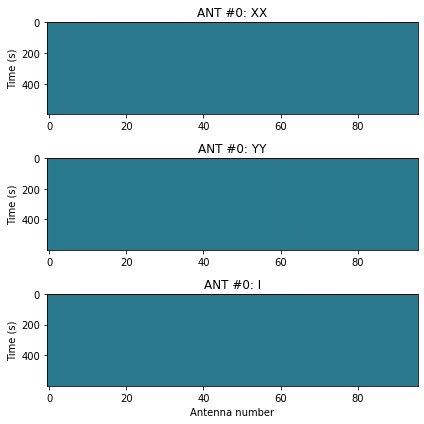

In [70]:
# Check how the various antennas/polarisation look with time
fig1, (ax0, ax1, ax2) = plt.subplots(nrows=3, ncols=1, figsize=(6,6))

ax0.imshow(cube_xx[:, 0, :].real, aspect='auto')
ax0.set_ylabel('Time (s)')
ax0.set_title('ANT #0: XX')
ax1.imshow(cube_yy[:,0,:].real,aspect='auto')
ax1.set_title('ANT #0: YY')
ax1.set_ylabel('Time (s)')
ax2.imshow(visibilities_all[:,0,:].real,aspect='auto')
ax2.set_title('ANT #0: I')
ax2.set_xlabel('Antenna number')
ax2.set_ylabel('Time (s)')
fig1.tight_layout()

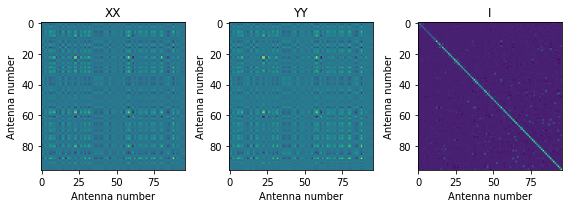

In [71]:
# Check how the correlations look
fig1, (ax0, ax1, ax2) = plt.subplots(nrows=1, ncols=3, figsize=(8,3))

ax0.imshow(cube_xx[0,:,:].real, aspect='auto')
ax0.set_xlabel('Antenna number')
ax0.set_ylabel('Antenna number')
ax0.set_title('XX')
ax1.imshow(cube_yy[0,:,:].real, aspect='auto')
ax1.set_title('YY')
ax1.set_xlabel('Antenna number')
ax1.set_ylabel('Antenna number')
ax2.imshow(visibilities.real, aspect='auto')
ax2.set_title('I')
ax2.set_xlabel('Antenna number')
ax2.set_ylabel('Antenna number')
fig1.tight_layout()

In [72]:
# Setup the database
db = LofarAntennaDatabase()

In [73]:
station_xyz, pqr_to_xyz = get_station_xyz(station_name, rcu_mode, db)

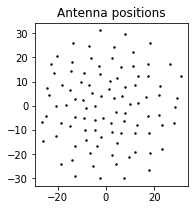

In [74]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.scatter(station_xyz[:, 0], station_xyz[:, 1], s=2, facecolor='k');
ax.set_title("Antenna positions");
ax.set_aspect(1);

In [75]:
# For every antenna, calculate the distance between it and every other antenna
station_xyz, pqr_to_xyz = get_station_xyz(station_name, rcu_mode, db)
baselines = station_xyz[:, np.newaxis, :] - station_xyz[np.newaxis, :, :]

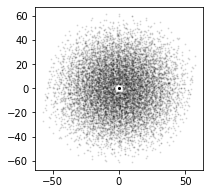

In [76]:
# Make a plot of the baselines contents (only U-V, not W)
# This gives the instantaneous U-V coverage of the LBA station
plt.figure(figsize=(3,3))
plt.scatter(baselines[:,:,0], baselines[:,:,1], facecolor='k', edgecolor='k', s=1, alpha=0.1);

In [77]:
#station_pqr = get_station_pqr(station_name, rcu_mode, db)

#baselines2 = station_pqr[:, np.newaxis, :] - station_pqr[np.newaxis, :, :]

#fig, ax = plt.subplots(figsize=(3, 3))
#ax.scatter(station_pqr[:, 0], station_pqr[:, 1], s=2, facecolor='k')
#ax.set_title("HBA Antennas (PQR)")

#plt.figure(figsize=(3,3))
#plt.scatter(baselines2[:,:,0], baselines2[:,:,1], facecolor='k', edgecolor='k', s=1, alpha=0.1);

In [78]:
# Account for the rotation
rotation = np.rad2deg(db.rotation_from_north(station_name))
print ('Rotation for %s: %.2f deg' % (station_name, rotation))

Rotation for LV614LBA: 12.73 deg


In [79]:
obstime_astropy = Time(obstime)
# Determine positions of Cas A and Cyg A
# Irbene station location:
station_name = get_full_station_name(station_name, rcu_mode)

print("Phase center:", db.phase_centres[station_name])
station_earthlocation = EarthLocation.from_geocentric(*(db.phase_centres[station_name] * u.m))

zenith = AltAz(az=0 * u.deg, alt=90 * u.deg, obstime=obstime_astropy,
               location=station_earthlocation).transform_to(GCRS(obstime=obstime_astropy))

#prueba_az = 15 * u.deg   # Gira en horizontal
#prueba_alt = 90 * u.deg # Baja un poco desde los 90 grados (cénit real)

#zenith = AltAz(az=prueba_az, alt=prueba_alt, obstime=obstime_astropy, 
#                    location=station_earthlocation).transform_to(GCRS(obstime=obstime_astropy))

marked_bodies = {
    #'Cas A': SkyCoord(ra="23h23m26.0s", dec="+58d48m41s", frame="icrs"),
    'Cas A': SkyCoord(ra=350.858*u.deg, dec=58.811*u.deg),
    'Cyg A': SkyCoord(ra=299.868*u.deg, dec=40.734*u.deg),
    #'Cyg A': SkyCoord(ra="19h41m48.9534996168s", dec="+50d31m30.219536784s", frame="icrs"), #more accurate coords
    #in ff 1st remove bright sources adnd milky way
    #sensitivity analysis
    #fraunhofer
    #test w signal gen in nf, knowing height
    #test from ff didnt have time
    
   # 'Per A': SkyCoord.from_name("Perseus A"),
    #'Her A': SkyCoord.from_name("Hercules A"),
    #'Cen A': SkyCoord.from_name("Centaurus A"),
#        '?': SkyCoord.from_name("J101415.9+105106"),
    #'3C147': SkyCoord.from_name("3C147"),
    #'Moon': get_body("moon",obstime_astropy, location=station_earthlocation).transform_to(GCRS(obstime=obstime_astropy)),
    'Sun': get_sun(obstime_astropy),
    #'3C48': SkyCoord.from_name("3C48")
}

############# NEW
marked_sats = {}
marked_sats_traj = {}   

from skyfield.api import wgs84, load

print(f"Lat: {station_earthlocation.lat.deg}, Lon: {station_earthlocation.lon.deg}, Alt: {station_earthlocation.height}")

# tranform astropy object to skyfield
station_location = wgs84.latlon(
    station_earthlocation.lat.deg, 
    station_earthlocation.lon.deg, 
    elevation_m=station_earthlocation.height.to(u.m).value
)

from datetime import timedelta

ts = load.timescale()
# t = ts.now()  # for real time
t = ts.utc(obstime.year, obstime.month, obstime.day, obstime.hour, obstime.minute, obstime.second)

######## for movement prediction
secs = np.arange(0, 300, 5) 
t_array = ts.utc(obstime.year, obstime.month, obstime.day, obstime.hour, obstime.minute, obstime.second + secs)

obstime_start = obstime - timedelta(days=1) # range of 1 day before observation to ensure most recent TLE at that time
start_date_str = obstime_start.strftime('%Y-%m-%d %H:%M:%S')
end_date_str = obstime.strftime('%Y-%m-%d %H:%M:%S')

from spacetrack import get_starlink_data

# load Starlink data
satellites = get_starlink_data(start_date_str, end_date_str)
# satellites = load.tle_file('https://celestrak.org/NORAD/elements/gp.php?GROUP=starlink&FORMAT=tle')

for sat in satellites:
    # relative position to Irbene
    difference = sat - station_location
    topocentric = difference.at(t) # TLE does not download the satellite's current position
                                   # but rather its orbital parameters.
                                   # It calculates the position using a mathematical model (SGP4) with .at(t)

    # obtain altitude and azimuth
    alt, az, distance = topocentric.altaz()

    # above horizon (Alt > 30)
    if alt.degrees > 30: 
        ra, dec, distance = topocentric.radec()
        # print(f"{sat.name}: Right ascension {ra.hours:.2f} h, Declination {dec.degrees:.2f}°")
        marked_sats[sat.name] = SkyCoord(ra=ra.hours*u.hourangle, dec=dec.degrees*u.deg)
        
        # save trajectory
        trajectory = difference.at(t_array)
        ra_traj, dec_traj, _ = trajectory.radec()
        marked_sats_traj[sat.name] = SkyCoord(ra=ra_traj.hours*u.hourangle, dec=dec_traj.degrees*u.deg)

marked_sats_lmn = {}
for sat_name, sat_coord in marked_sats.items():
    marked_sats_lmn[sat_name] = skycoord_to_lmn(marked_sats[sat_name], zenith)
    
marked_sats_traj_lmn = {}
for sat_name, sat_traj in marked_sats_traj.items():
    marked_sats_traj_lmn[sat_name] = skycoord_to_lmn(sat_traj, zenith)

# print(marked_sats)
# print(marked_sats_lmn)

marked_bodies_lmn = {}
for body_name, body_coord in marked_bodies.items():
    #print(body_name, body_coord.separation(zenith), body_coord.separation(zenith))
    if body_coord.transform_to(AltAz(location=station_earthlocation, obstime=obstime_astropy)).alt > 0:
        marked_bodies_lmn[body_name] = skycoord_to_lmn(marked_bodies[body_name], zenith)
        
marked_all_lmn = {**marked_bodies_lmn, **marked_sats_lmn}

Phase center: [3183318.573 1276777.346 5359434.837]
Lat: 57.55688026014763, Lon: 21.85491897084111, Alt: 13.28916250819648 m
Data downloaded, converting to Skyfield objects...


In [80]:
# Fourier transform
%time img = sky_imager(visibilities, baselines, freq, npix_l, npix_m)

CPU times: total: 22.3 s
Wall time: 4.88 s


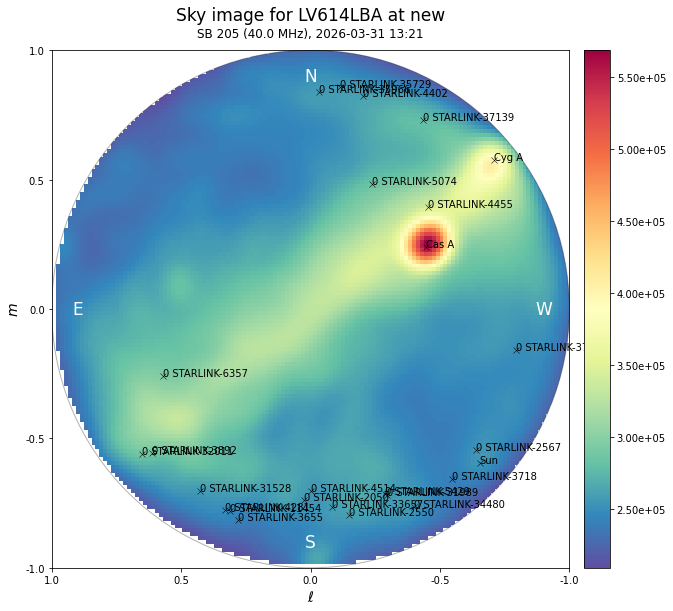

In [81]:
test_site = data_dir.split('/')[-1].split('_')[0]
fig = make_sky_plot(img, marked_all_lmn, title=f"Sky image for {station_name} at {test_site}",
                   subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}");

fig.savefig(os.path.join('results', f'{fname}_w_sources.png'), bbox_inches='tight', dpi=200)
#check why this isn't correctly aligned

In [82]:
from lofarimaging import subtract_sources

In [83]:
visibilities_subtracted = subtract_sources(visibilities, baselines, freq, marked_bodies_lmn)

In [170]:
img_subtracted = sky_imager(visibilities_subtracted, baselines, freq, npix_l, npix_m)

from astropy.convolution import Gaussian2DKernel, interpolate_replace_nans

rows, cols = img_subtracted.shape
Y_g, X_g = np.ogrid[:rows, :cols]
source_mask_radius = 15

cy, cx = rows // 2, cols // 2
circle_mask = np.sqrt((X_g - cx)**2 + (Y_g - cy)**2) > (min(cx, cy) - 1)

# sources' mask
sources_mask = np.zeros((rows, cols), dtype=bool)

for body_name, (l_s, m_s, n_s) in marked_bodies_lmn.items():
    # Convert sky coordinates (l, m) to pixel indices (col, row)
    px = int((1 - l_s) / 2 * (cols - 1))
    py = int((1 + m_s) / 2 * (rows - 1))
    
    #if the source's center is not inside image array
    if 0 <= px < cols and 0 <= py < rows:
        #apply mathematical equation for circle (x - px)^2 + (y-py)^2 < r^2
        #all_sources_mask = TRUE for pixels within source_mask_radius of (px, py)
        sources_mask |= ((X_g - px)**2 + (Y_g - py)**2 < source_mask_radius**2) 

img_masked = img_subtracted.copy()

# 2. Vaciamos (NaN) las fuentes y el exterior para que Astropy los ignore al calcular
img_masked[sources_mask] = np.nan
img_masked[circle_mask] = np.nan

# 3. Interpolamos. Astropy solo usará los números válidos para rellenar los huecos.
# Usa un x_stddev grande (ej. 8 o 10) para cubrir bien un radio de 15px.
kernel = Gaussian2DKernel(x_stddev=4)
img_masked = interpolate_replace_nans(img_masked, kernel)

from scipy.ndimage import gaussian_filter

# Aplica un suavizado ligero (mezcla el parche con el fondo)
img_masked = gaussian_filter(img_masked, sigma=2)

# 4. Aseguramos el borde exterior circular perfecto
img_masked[circle_mask] = np.nan

############ FOURIER TRANSFORM: spatial frequency
f_transform = np.fft.fft2(np.nan_to_num(img_masked))
f_shift = np.fft.fftshift(f_transform)

# the center corresponds to slow spatial frequency (big structures like Milky Way)
# rows, cols = size of image in pixels
rows = npix_l
cols = npix_m
center_row, center_col = rows//2 , cols//2 # to find center pixels, just divide by 2 the total size

# low spatial frequencies are deleted by 10x10 square of 0 value: HPF
# f_shift[center_row-5:center_row+5, center_col-5:center_col+5] = 0

# Use of Gaussian HPF instead of rectangular HPF: small objects are "cleaner" with Gaussian shape
# sigma is the point where the filter lets 1/3 of the signal pass
# The higher the sigma, wider the pass band (more permissive filter)
sigma = 10

y, x = np.ogrid[-center_row:rows-center_row, -center_col:cols-center_col]
d = x**2 + y**2

# Gaussian HPF: 0 in center, going up to 1
# 1 - exp(-d^2 / (2 * sigma^2))
ghpf = 1 - np.exp(-d / (2 * sigma**2))
f_shift = f_shift * ghpf

# Back to pixels
f_ishift = np.fft.ifftshift(f_shift)
img_fftclean = np.real(np.fft.ifft2(f_ishift))

# img_fftclean = img_fftclean - np.median(img_fftclean)
std_fftclean = np.nanstd(img_fftclean)


#################### OTHER METHODS TRIED:

# Median subtraction to normalize, using .nanmedian to ignore NaN values on the borders of the matrix
# nanmedian calculates a single numerical value for the entire image
img_subtracted_normalized = img_subtracted - np.nanmedian(img_subtracted)

# Standard deviation value
std_val = np.nanstd(img_subtracted_normalized)

############ MEDIAN_FILTER calculated a pixel-by-pixel median by looking only at its nearest neighbors
# this is set by the size of the square defined
from scipy.ndimage import median_filter

img_temp = np.nan_to_num(img_subtracted, nan=0.0)

background_noise = median_filter(img_temp, size=100) 

img_clean = img_subtracted - background_noise
std_clean = np.nanstd(img_clean)

######### WAVELET
import pywt

# wavelet decomposition (using Daubechies)
#level defines how big the area we want to remove is
coeffs = pywt.wavedec2(img_temp, 'db4', level=2)

# Remove aproximation coefficient
coeffs_list = list(coeffs)
coeffs_list[0] = np.zeros_like(coeffs_list[0])

# Rebuild image with just detail coefficients
img_wavelet = pywt.waverec2(tuple(coeffs_list), 'db4')
std_wavelet = np.nanstd(img_wavelet)

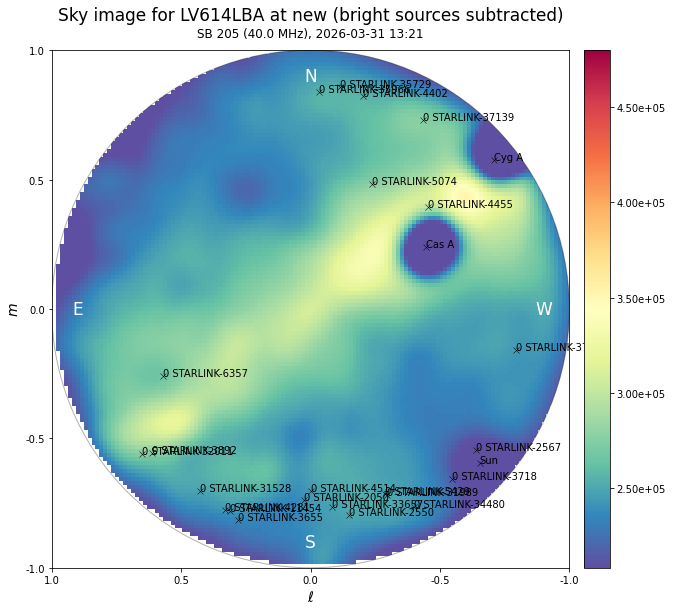

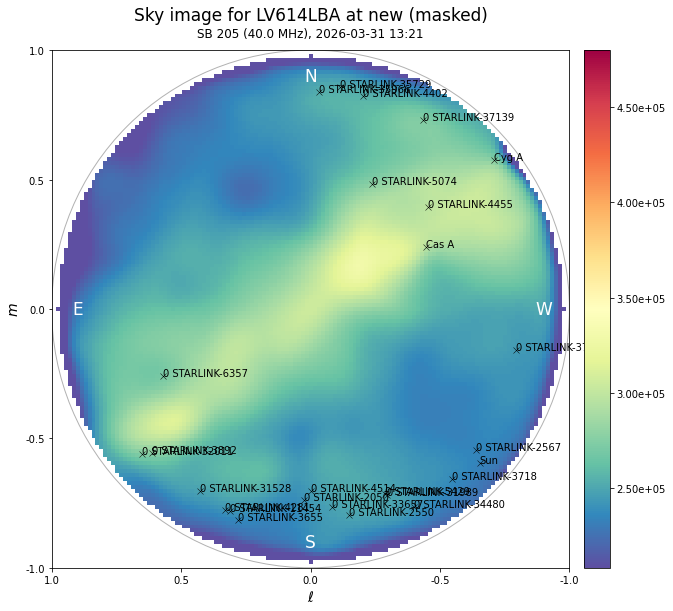

In [171]:
fig0 = make_sky_plot(img_subtracted, marked_all_lmn, title=f"Sky image for {station_name} at {test_site} (bright sources subtracted)",
                    subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}",
                   vmin=np.nanquantile(img_subtracted,0.05), vmax = 4.8e5);

fig0.savefig(os.path.join('results', f'{fname}_subtracted.png'), bbox_inches='tight', dpi=200)

fig00 = make_sky_plot(img_masked, marked_all_lmn, title=f"Sky image for {station_name} at {test_site} (masked)",
                    subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}",
                   vmin=np.nanquantile(img_subtracted,0.05), vmax = 4.8e5);
fig00.savefig(os.path.join('results', f'{fname}_masked.png'), bbox_inches='tight', dpi=200)

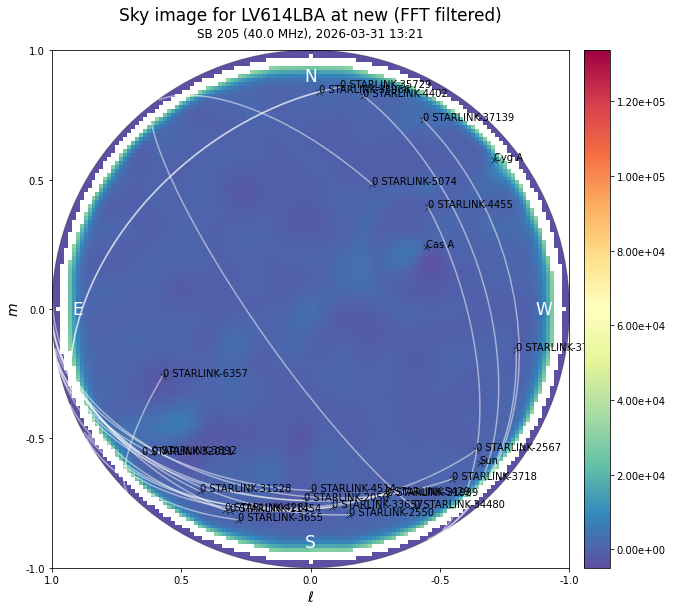

In [172]:
img_fftclean[img_fftclean > np.nanpercentile(img_fftclean, 95)] = np.nan # np.nanmedian(img_fftclean)

########## WITH FFT FILTERING
fig_clean = make_sky_plot(img_fftclean, marked_all_lmn, title=f"Sky image for {station_name} at {test_site} (FFT filtered)",
                    subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}",  
                    vmin=-0.5e4, vmax=6*std_fftclean); #vmin = -std_fftclean, 0, ?????
for sat_name, (l, m, n) in marked_sats_traj_lmn.items():
    fig_clean.axes[0].plot(l, m, color='white', linestyle='-', alpha=0.5)
    
fig_clean.savefig(os.path.join('results', f'{fname}_filtered_sat_traj.png'), bbox_inches='tight', dpi=200)

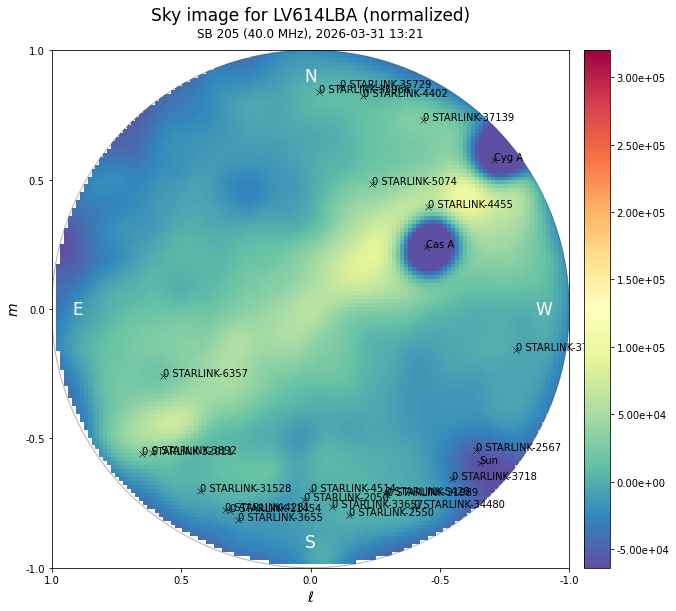

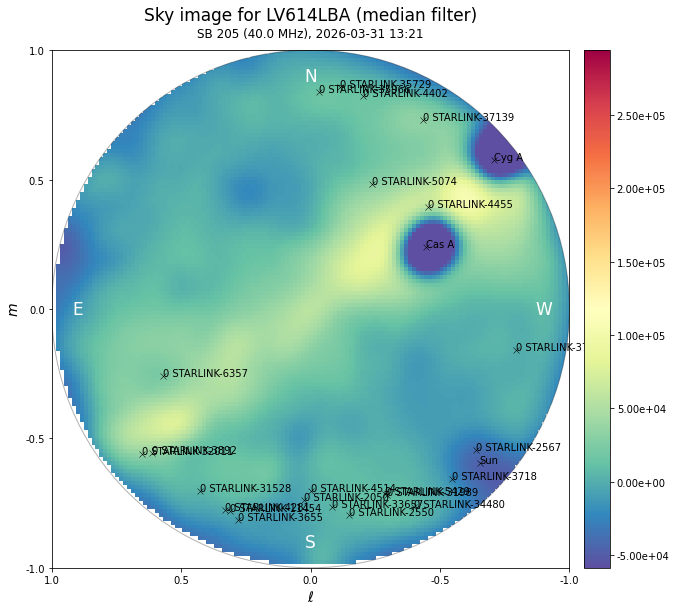

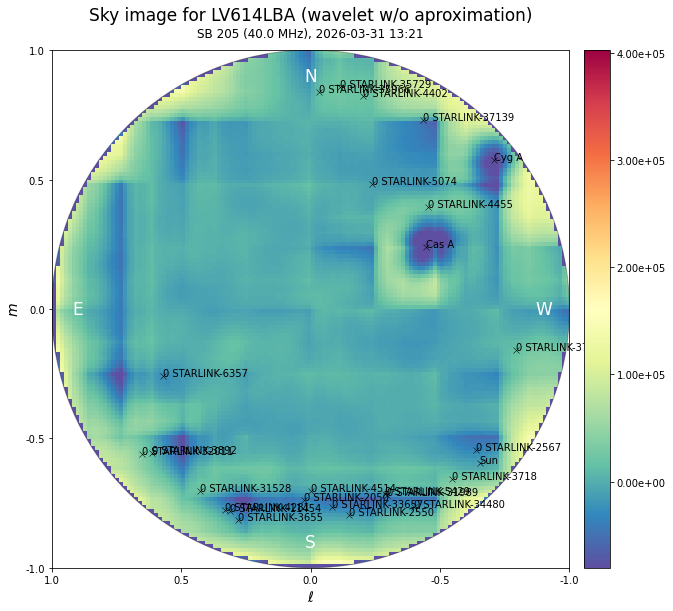

In [173]:
############# WITH NANMEDIAN
fig2 = make_sky_plot(img_subtracted_normalized, marked_all_lmn, title=f"Sky image for {station_name} (normalized)",
                    subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}", 
                    vmin=-2*std_val, vmax=10*std_val);
vmin=np.quantile(img_subtracted_normalized, 0.05)

########## WITH MEDIAN_FILTER
fig3 = make_sky_plot(img_clean, marked_all_lmn, title=f"Sky image for {station_name} (median filter)",
                    subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}", 
                    vmin=-2*std_clean, vmax=10*std_clean);

########## WITH WAVELETS
fig5 = make_sky_plot(img_wavelet, marked_all_lmn, title=f"Sky image for {station_name} (wavelet w/o aproximation)",
                    subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}", 
                    vmin=-2*std_wavelet, vmax=10*std_wavelet);

## Video

In [88]:
from satellitemov import make_sky_video

In [89]:
#gif_path = make_sky_video(visibilities_all, baselines, freq, marked_all_lmn, marked_sats_traj_lmn, station_name, 
 #                       subband, obstime, fname, t_end=visibilities_all.shape[0], step=10)
#print(f"Video ready at: {gif_path}!")

  Frame 60/60
All frames done
GIF saved: ./videoresult\20260331_132108_LV614LBA_SB205_skyvideo_fps5.gif
Video ready at: ./videoresult\20260331_132108_LV614LBA_SB205_skyvideo_fps5.gif!


In [90]:
########-------------- NEAR FIELD
plt.close(fig_clean)

In [91]:
npix_x, npix_y = int(ground_resolution * (extent[1] - extent[0])), int(ground_resolution * (extent[3] - extent[2]))

In [92]:
import lofargeotiff

In [93]:
# Convert bottom left and upper right to PQR just for lofargeo
pmin, qmin, _ = pqr_to_xyz.T @ (np.array([extent[0], extent[2], 0]))
pmax, qmax, _ = pqr_to_xyz.T @ (np.array([extent[1], extent[3], 0]))
lon_center, lat_center, _ = lofargeotiff.pqr_to_longlatheight([0, 0, 0], station_name)
lon_min, lat_min, _ = lofargeotiff.pqr_to_longlatheight([pmin, qmin, 0], station_name)
lon_max, lat_max, _ = lofargeotiff.pqr_to_longlatheight([pmax, qmax, 0], station_name)

In [94]:
background_map = get_map(lon_min, lon_max, lat_min, lat_max, 18)

In [95]:
#n_timesteps = 2  

#nearfield_imgs = []
#for t_idx in range(n_timesteps):
#    vis_t = visibilities_all[t_idx]    
#    baseline_index = np.tril_indices(vis_t.shape[0])
#    vis_sub_t = subtract_sources(vis_t, baselines, freq, marked_bodies_lmn)

 #   vis_selection = vis_sub_t[baseline_index]
    
 #   img_t = nearfield_imager(
 #       vis_selection.flatten()[:, np.newaxis],
 #       np.array(baseline_index).T,
 #       [freq], npix_x, npix_y, extent, station_xyz, height=height
 #   )
 #   img_t = np.real(2 * img_t)
 #   nearfield_imgs.append(img_t)

# difference: to cancel the lateral "blobs" of bright sources that couldn't be deleted in allsky image
#diff = nearfield_imgs[1] - nearfield_imgs[0]
#plt.imshow(diff)

#std_d = np.nanstd(diff)
#fig_diff, folium_overlay_diff = make_ground_plot(diff, background_map, extent, 
#    title=f"Near field: difference t1-t0 — {station_name}",
#    subtitle=f"SB {subband} ({freq/1e6:.1f} MHz), {str(obstime)[:16]}", opacity=0.7)

#maxpix_y, maxpix_x = np.unravel_index(np.argmax(np.abs(diff)), diff.shape)
#max_x = np.interp(maxpix_x, [0, npix_x], [extent[0], extent[1]])
#max_y = np.interp(maxpix_y, [0, npix_y], [extent[2], extent[3]])
#[max_p, max_q, _] = pqr_to_xyz.T @ np.array([max_x, max_y, height])
#max_lon, max_lat, _ = lofargeotiff.pqr_to_longlatheight([max_p, max_q], station_name)

#plt.show()

In [96]:
os.environ["NUMEXPR_NUM_THREADS"] = "3"

In [97]:
# Select a subset of visibilities, only the lower triangular part
baseline_indices = np.tril_indices(visibilities.shape[0])

In [98]:
visibilities_selection = visibilities_subtracted[baseline_indices]

In [99]:
%time img = nearfield_imager(visibilities_selection.flatten()[:,np.newaxis], \
                             np.array(baseline_indices).T, \
                             [freq], npix_x, npix_y, extent, station_xyz, height=height)
# Correct for taking only lower triangular part
img = np.real(2 * img)

CPU times: total: 1min 27s
Wall time: 36 s


In [100]:
# FFT FILTERING (same as in far field because if not, bright sources dominate) idk if i have to do this or not 
f_transform = np.fft.fft2(np.nan_to_num(img))
f_shift = np.fft.fftshift(f_transform)

rows, cols = npix_x, npix_y
center_row, center_col = rows//2 , cols//2 

# Gaussian HPF setup (sigma controls how aggressively we delete the blobs)
sigma = 6
y, x = np.ogrid[-center_row:rows-center_row, -center_col:cols-center_col]
d = x**2 + y**2
ghpf = 1 - np.exp(-d / (2 * sigma**2))

# Apply filter and invert
f_shift = f_shift * ghpf
f_ishift = np.fft.ifftshift(f_shift)
img_filtered = np.real(np.fft.ifft2(f_ishift))

In [101]:
import lofargeotiff

In [102]:
# Make colors semi-transparent in the lower 3/4 of the scale
cmap = cm.Spectral_r
cmap_with_alpha = cmap(np.arange(cmap.N))
cmap_with_alpha[:, -1] = np.clip(np.linspace(0, 1.5, cmap.N), 0., 1.)
cmap_with_alpha = ListedColormap(cmap_with_alpha)

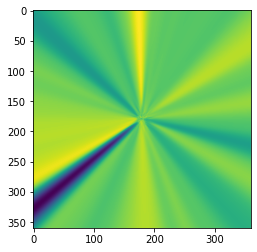

In [103]:
for sat in satellites:
    # get the satellite's position at time 't'
    geocentric = sat.at(t)
    
    # get geographic coordinates
    subpoint = geocentric.subpoint()
    sat_lat = subpoint.latitude.degrees
    sat_lon = subpoint.longitude.degrees
    
    # check if satellite is within map boundaries
    if (lon_min <= sat_lon <= lon_max) and (lat_min <= sat_lat <= lat_max):
        ax.plot(sat_lon, sat_lat, marker='x', color='white', markersize=8, zorder=10)
        ax.text(sat_lon + 0.05, sat_lat, f" {sat.name}", color='white', fontsize=9, zorder=10)
        
plt.imshow(img)

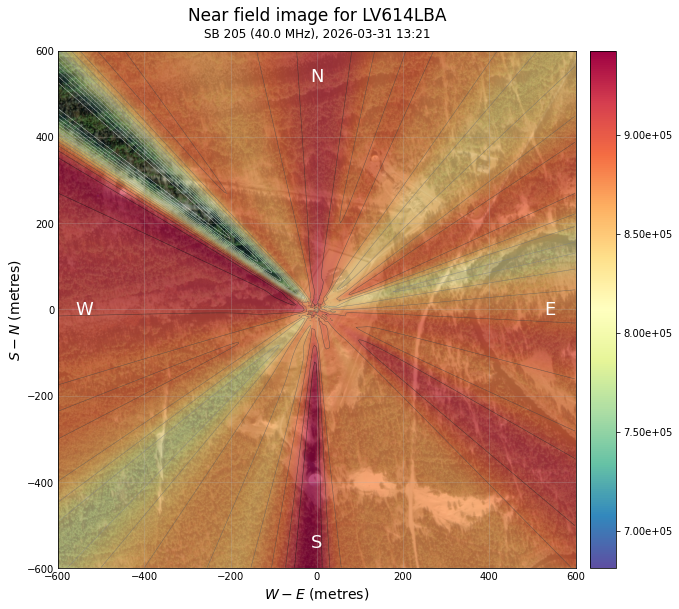

In [104]:
fig, folium_overlay = make_ground_plot(img, background_map, extent,
                                       title=f"Near field image for {station_name}",
                                       subtitle=f"SB {subband} ({freq / 1e6:.1f} MHz), {str(obstime)[:16]}",
                                       opacity=0.7)

In [105]:
maxpixel_ypix, maxpixel_xpix = np.unravel_index(np.argmax(img_filtered), img_filtered.shape)
maxpixel_x = np.interp(maxpixel_xpix, [0, npix_x], [extent[0], extent[1]])
maxpixel_y = np.interp(maxpixel_ypix, [0, npix_y], [extent[2], extent[3]])
[maxpixel_p, maxpixel_q, _] = pqr_to_xyz.T @ np.array([maxpixel_x, maxpixel_y, height])
maxpixel_lon, maxpixel_lat, _ = lofargeotiff.pqr_to_longlatheight([maxpixel_p, maxpixel_q], station_name)

In [106]:
# Show location of maximum if not at the image border
if 5 < maxpixel_xpix < npix_x - 5 and 5 < maxpixel_ypix < npix_y - 5:
    print(f"Maximum at {maxpixel_x:.0f}m east, {maxpixel_y:.0f}m north of station center (lat/long {maxpixel_lat:.5f}, {maxpixel_lon:.5f})")

In [107]:
# Check total time to run
end1 = time.time()
print ('Time elapsed: %.2f s' % (end1-start1))

Time elapsed: 9643.10 s


Export the near field image to GeoTIFF for archiving and viewing in other tools (QGIS).

In [108]:
obstime = datetime.datetime.strptime(obsdatestr + ":" + obstimestr, '%Y%m%d:%H%M%S')

In [109]:
tags = {"datafile": xst_filename,
        "generated_with": f"lofarimaging notebook",
        "subband": subband,
        "frequency": freq,
        "extent_xyz": extent,
        "height": height,
        "station": station_name,
        "pixels_per_metre": pixels_per_metre}
tags.update(calibration_info)
lofargeotiff.write_geotiff(img, f"results/{fname}_nearfield_calibrated.tiff",
                           (pmin, qmin), (pmax, qmax), stationname=station_name,
                           obsdate=obstime, tags=tags)

Overlay the near field image on a map.


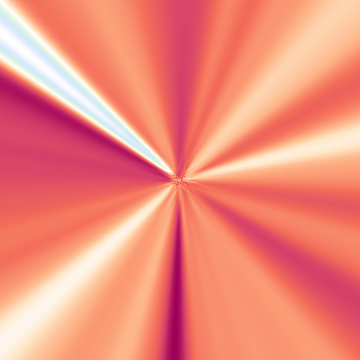

In [110]:
make_leaflet_map(folium_overlay, lon_center, lat_center, lon_min, lat_min, lon_max, lat_max)